##  How well do jobs and skills pay for Data Analysts?

1.Evaluate median salary for all data jobs
2.Find median salary per skill for Data Analysts
3.Visualize for highest paying skills
4.Visualize for higest demanded skills

In [2]:
#Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading the dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_US=df[df['job_location']=='United States'].dropna(subset=['salary_year_avg']).copy()

In [5]:
job_titles=df_US['job_title_short'].value_counts().index[:6].tolist()

In [6]:
df_US_top6=df_US[df_US['job_title_short'].isin(job_titles)]

In [14]:
order=df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

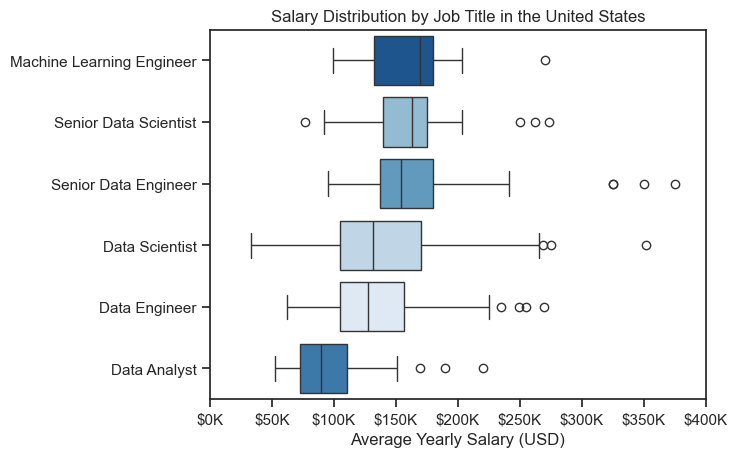

In [18]:
sns.boxplot(data=df_US_top6,x='salary_year_avg',y='job_title_short',order=order,orient='h',palette='Blues',hue='job_title_short')
sns.set_theme(style='ticks')

plt.title('Salary Distribution by Job Title in the United States')
plt.xlabel('Average Yearly Salary (USD)')
ax=plt.gca()
plt.ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, post: f'${int(x/1000)}K'))
plt.xlim(0,400000)
plt.show()

In [4]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])

In [5]:
df_DA_US=df_DA_US.explode('job_skills')

In [7]:
df_DA_top_pay=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values('median',ascending=False).head(10)


In [23]:
df_DA_top_skills=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_skills=df_DA_top_skills.sort_values('count',ascending=False).head(10)
df_DA_top_skills=df_DA_top_skills.sort_values('median',ascending=True)

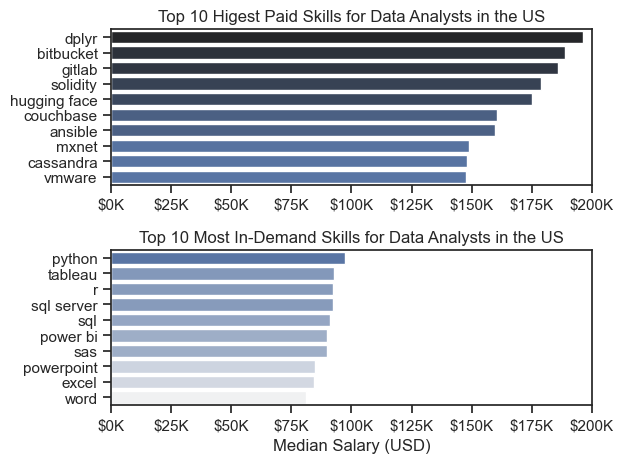

In [24]:
fig, ax=plt.subplots(2,1)
#df_DA_top_pay['median'].plot(kind='barh',ax=ax[0],title='Top 10 Skills by Median Salary',legend=False)
sns.barplot(data=df_DA_top_pay,x=df_DA_top_pay['median'],y=df_DA_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r')
sns.set_theme(style='ticks')
#ax[0].invert_yaxis()
ax[0].legend_.remove()
ax[0].set_xlim(0,200000)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Top 10 Higest Paid Skills for Data Analysts in the US')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
#df_DA_top_skills['median'].plot(kind='barh',ax=ax[1],title='Top 10 Skills by Count',legend=False)
sns.barplot(data=df_DA_top_skills,x=df_DA_top_skills['median'],y=df_DA_top_skills.index,ax=ax[1],hue='median',palette='light:b')
ax[1].legend_.remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts in the US')
ax[1].set_xlim(0,200000)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlabel('Median Salary (USD)')
plt.tight_layout()
plt.show()